# Build and Test Clustering 

Using subject (genre), category, page counts, published date

#### Imports and Data 

In [92]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS


In [93]:
df = pd.read_csv("../data/books.csv")
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")
print(df.shape)
df.head()

(585, 11)


,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description
0,The Dream of the Celt,Mario Vargas Llosa,Macmillan + ORM,fiction,Fiction,NOT_MATURE,455,0.0,0,2012-06-05,"This ""vast and intriguing novel"" explores the ..."
1,The Natural,Bernard Malamud,Macmillan,fiction,Fiction,NOT_MATURE,250,0.0,0,1952-01-01,Story of a baseball player's record-shattering...
2,Journey to the Center of the Earth,Jules Verne,Bantam,fiction,Fiction,NOT_MATURE,242,3.5,3,2006-04-25,The intrepid Professor Lindenbrock embarks upo...
3,Mysteries,Knut Hamsun,Penguin,fiction,Fiction,NOT_MATURE,356,4.0,3,2001-01-01,The first complete English translation of the ...
4,Cat's Cradle,Kurt Vonnegut,Dial Press Trade Paperback,fiction,Fiction,NOT_MATURE,308,4.0,147,1998-09-08,“A free-wheeling vehicle . . . an unforgettabl...


#### Publishing Year extract 

In [94]:
#just get year 
df["publish_year"] = df["published_date"].dt.year

In [95]:
#check for missing dates 
df["publish_year"].isna().sum()

#if missing dates, fill with median year
median_year = df["publish_year"].median()
df["publish_year"] = df["publish_year"].fillna(median_year)

In [96]:
#year range 
print(f"publish year range: {df['publish_year'].min()} - {df['publish_year'].max() }")

publish year range: 1952 - 2025


#### normalize page counts and publish year 

In [97]:
scaler = MinMaxScaler()

#scale to be between 0 and 1 for clustering
# df["page_count_scaled"] = scaler.fit_transform(df[["page_count"]])
# df["publish_year_scaled"] = scaler.fit_transform(df[["publish_year"]])
df[["page_count_scaled", "publish_year_scaled"]] = scaler.fit_transform(df[["page_count", "publish_year"]])

#confirm 
print(df[["page_count_scaled", "publish_year_scaled"]].describe())


       page_count_scaled  publish_year_scaled
count         585.000000           585.000000
mean            0.148224             0.697600
std             0.089521             0.215847
min             0.000000             0.000000
25%             0.095576             0.575342
50%             0.131469             0.739726
75%             0.180718             0.890411
max             1.000000             1.000000


#### Encode genres and categories

In [98]:
#turn genre into indicator columns with one hot encoding
subject_dummies = pd.get_dummies(df["subject"], prefix="subject")
subject_dummies.head()

,subject_biography,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_science,subject_science fiction,subject_self help,subject_thriller
0,False,True,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False


In [99]:
#turn categories into indicator columns with one hot encoding

#first deal with instances of list of categories 
category_dummies = df["categories"].str.get_dummies(sep=",")
#add prefix to columns
category_dummies.columns = ["category_"+col for col in category_dummies.columns]
category_dummies.head()

,category_ 1921-1922,category_ Ancient,"category_ Charlie ""Bird"" (Fictitious character)",category_ English,category_ Mind & Spirit,category_ The,category_Absolute,category_Abused women,category_Adaptability (Psychology),category_Adventure fiction,...,category_Religion,category_Science,category_Self,category_Self-Help,category_Social Science,category_Technology & Engineering,category_Thriller - Fiction,category_Travel,category_Unknown,category_Young Adult Nonfiction
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [100]:
#keep categories that appear in at least 5 books 
cat_columns = category_dummies.columns.tolist()
keep_cats = [col for col in cat_columns if category_dummies[col].sum() >= 5]

print("before category columns: ", len(cat_columns))
print("after category columns: ", len(keep_cats))

before category columns:  93
after category columns:  20


#### Add in TF-IDF to extract key words from description

In [101]:
df["description"] = df["description"].fillna("")

#create stop words list 
custom_stopwords = [
    # your original list
    'author', 'bestselling', 'book', 'books', 'novel', 'story', 'edition', 
    'fiction', 'history', 'just', 'make', 'man', 'new', 'readers', 'set', 
    'times', 'way', 'woman', 'written', 'years', 'york', 'best', 'literature', 
    'novels', 'published', 'research', 'science', 'series', 'stories', 'like', 
    'life', 'lives', 'home', 'world', 'time', 'people', 'long', 'old', 'young', 
    'great', 'known', 'journey', 'past', 'future', 'age', 'year',
    'including', 'important', 'information', 'use', 'work', 'works',
    'understanding', 'second', 'explores', 'finds', 'takes', 'offers', 'provides', 'read',
    'end', 'day', 'tale', 'ways', 'classic', 'original', 'comes', 'need', 'small', 'questions', 'public', 'personal',
    'authors', 'based', 'clear', 'different', 'experience', 'little', 'secrets', 'american'



]
all_stop_words = list(ENGLISH_STOP_WORDS.union(custom_stopwords))

#tf-idf, max features 50 
tfidf = TfidfVectorizer(
    max_features=50, #50 most meaningful words 
    stop_words = all_stop_words,
    min_df = 3 #word must appear in at least 3 books 
)

tfidf_matrix = tfidf.fit_transform(df['description']).toarray()
tfidf_df = pd.DataFrame(
    tfidf_matrix,
    columns = [f"tfidf_{term}" for term in tfidf.get_feature_names_out()]
)

print(f"tf-idf terms created: {tfidf_df.shape[1]}")
print("top words ", tfidf.get_feature_names_out().tolist())

tf-idf terms created: 50
top words  ['america', 'ancient', 'art', 'biography', 'body', 'brings', 'career', 'century', 'change', 'child', 'children', 'city', 'complex', 'comprehensive', 'cultural', 'dead', 'death', 'development', 'early', 'family', 'father', 'field', 'guide', 'help', 'historical', 'human', 'introduction', 'love', 'men', 'modern', 'murder', 'nature', 'philosophy', 'political', 'power', 'real', 'scientific', 'scientists', 'secret', 'self', 'social', 'society', 'study', 'technology', 'tells', 'theory', 'thought', 'truth', 'war', 'women']


#### combine all features

In [102]:
features = pd.concat([
    df[["page_count_scaled", "publish_year_scaled"]],
    subject_dummies,
    category_dummies[keep_cats],
    tfidf_df
], axis = 1)



In [103]:
print("features shape: ", features.shape)
features.head()

features shape:  (585, 81)


,page_count_scaled,publish_year_scaled,subject_biography,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_science,subject_science fiction,subject_self help,...,tfidf_social,tfidf_society,tfidf_study,tfidf_technology,tfidf_tells,tfidf_theory,tfidf_thought,tfidf_truth,tfidf_war,tfidf_women
0,0.181970,0.821918,False,True,False,False,False,False,False,False,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
1,0.096411,0.000000,False,True,False,False,False,False,False,False,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,0.093072,0.739726,False,True,False,False,False,False,False,False,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3,0.140651,0.671233,False,True,False,False,False,False,False,False,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.732789,0.0,0.0,0.339074
4,0.120618,0.630137,False,True,False,False,False,False,False,False,...,0.519915,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000


In [104]:
#check null 
features.isna().sum().sum()

np.int64(0)

In [ ]:
#df[df["categories"] == "Unknown"]

,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description,publish_year,page_count_scaled,publish_year_scaled
10,The House of the Seven Gables,Nathaniel Hawthorne,CreateSpace,fiction,Unknown,NOT_MATURE,250,0.0,0,2015-04-11,The House of the Seven Gables By Nathaniel Haw...,2015,0.096411,0.863014
12,The Scarlet Letter Annotated,Nathaniel Hawthorne,Unknown,fiction,Unknown,NOT_MATURE,316,0.0,0,2021-01-05,"Set in an early New England colony, the novel ...",2021,0.123957,0.945205
18,The Tragedy of King Lear,William Shakespeare,Unknown,fiction,Unknown,NOT_MATURE,124,0.0,0,2020-12-22,King Lear is a tragedy written by William Shak...,2020,0.043823,0.931507
21,Pride and Prejudice,Jane Austen,Createspace Independent Publishing Platform,fiction,Unknown,NOT_MATURE,330,0.0,0,2017-09-29,Elizabeth Bennet is Austen's most liberated an...,2017,0.129800,0.890411
24,Typee Illustrated,Herman Melville,Unknown,fiction,Unknown,NOT_MATURE,406,0.0,0,2019-11-26,Typee: A Peep at Polynesian Life is the first ...,2019,0.161519,0.917808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,Artificial Intelligence For Dummies,John Mueller,Unknown,nonfiction,Unknown,NOT_MATURE,336,0.0,0,2018-01-01,"Step into the future with AI The term ""Artific...",2018,0.132304,0.904110
552,Ride the Devil's Herd,John Boessenecker,Hanover Square Press,nonfiction,Unknown,NOT_MATURE,512,0.0,0,2021-11-02,"""A ripsnortin' ramble across the bloodstained ...",2021,0.205760,0.945205
562,Underland,Robert Macfarlane,Hamish Hamilton,nonfiction,Unknown,NOT_MATURE,496,0.0,0,2019-05-02,The highly anticipated new book from the inter...,2019,0.199082,0.917808
575,Astrology,Dorling Kindersley Publishing Staff,Unknown,nonfiction,Unknown,NOT_MATURE,256,0.0,0,2018-09-01,Find out how to use your birth horoscope to en...,2018,0.098915,0.904110


### K Means

Find K value - elbow method 

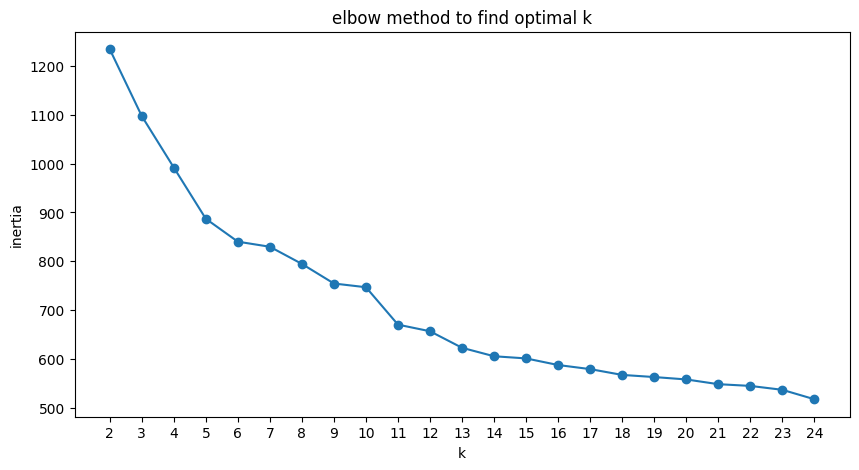

In [106]:
inertia = [] #track how tight clusters are
k_range = range(2, 25)

#test out ks 
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

#plot inertia to find elbow point
plt.figure(figsize=(10,5))
plt.plot(k_range, inertia, marker="o")
plt.title("elbow method to find optimal k")
plt.xlabel("k")
plt.ylabel("inertia")
plt.xticks(k_range)
plt.show()

somewhere in k = 14


In [107]:
for k in [11, 12]:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    df[f"cluster_{k}"] = kmeans.labels_
    print(f"\n{k} clusters")
    print(df[f"cluster_{k}"].value_counts().sort_index())


11 clusters
cluster_11
0       6
1      61
2      82
3       9
4      58
5     100
6      90
7      37
8      38
9      27
10     77
Name: count, dtype: int64

12 clusters
cluster_12
0       6
1      61
2      69
3       9
4      58
5     101
6      89
7      37
8      37
9      27
10     77
11     14
Name: count, dtype: int64


In [112]:
for cluster_id in [0, 3]:
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_books = df[df["cluster_11"] == cluster_id]
    print("Subjects:", cluster_books["subject"].value_counts().to_dict())
    print("Categories:", cluster_books["categories"].value_counts().head(5).to_dict())
    print("Titles:", cluster_books["title"].tolist())


--- Cluster 0 ---
Subjects: {'self help': 6}
Categories: {'Family & Relationships': 6}
Titles: ['Self and Family', 'Weaning and Human Development', 'Motherself', 'Radical Self-acceptance', 'Interpersonal Boundaries', 'Early Adolescence and the Search for Self']

--- Cluster 3 ---
Subjects: {'thriller': 9}
Categories: {'Art museum curators': 1, 'Thriller - Fiction': 1, 'Adventure fiction': 1, 'Adventure stories': 1, 'Parker, Charlie "Bird" (Fictitious character)': 1}
Titles: ['The Da Vinci Code', 'City of Bones', 'The Waste Lands', 'Area 7', 'A Song of Shadows', 'Long Road to Mercy', 'The Terminal Man', 'Catching Fire', "Daddy's Little Girl"]


k = 11 best 


In [113]:
kmeans = KMeans(n_clusters=11, random_state=123, n_init=10)
kmeans.fit(features)
df["cluster"] = kmeans.labels_

print(df["cluster"].value_counts().sort_index())

cluster
0     35
1     77
2     97
3     53
4     83
5     57
6     32
7     42
8     26
9     47
10    36
Name: count, dtype: int64


### PCA 

In [114]:
pca = PCA(n_components=2, random_state=123)
pca_features = pca.fit_transform(features)

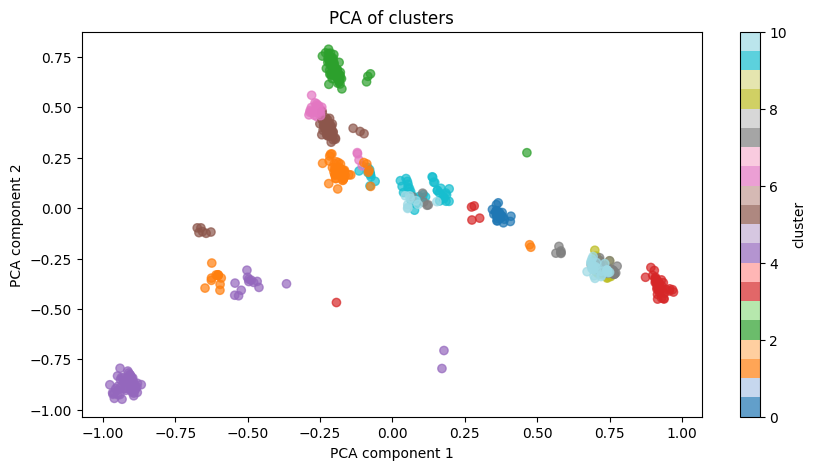

In [115]:
#plot PCA components colored by cluster
plt.figure(figsize=(10,5))
scatter = plt.scatter(
    pca_features[:,0], #x axis , first PCA component
    pca_features[:,1], #y axis, second PCA component
    c=df["cluster"],  # color by cluster assignment
    cmap="tab20", #20 distinct colors
    alpha=0.7
)
plt.colorbar(scatter, label="cluster")
plt.title("PCA of clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

look at each cluster 

In [116]:
for i in range(11):
    print(f"cluster {i}")
    cluster_books = df[df["cluster"] == i]
    print("subjects: ", cluster_books["subject"].value_counts().to_dict())
    print("categories: ", cluster_books["categories"].value_counts().to_dict())
    print("titles: ", cluster_books["title"].tolist()[:5]) 


cluster 0
subjects:  {'fiction': 35}
categories:  {'Unknown': 35}
titles:  ['The House of the Seven Gables', 'The Scarlet Letter Annotated', 'The Tragedy of King Lear', 'Pride and Prejudice', 'Typee Illustrated']
cluster 1
subjects:  {'nonfiction': 77}
categories:  {'Biography & Autobiography': 12, 'History': 8, 'Business & Economics': 7, 'Juvenile Nonfiction': 5, 'Unknown': 5, 'Nature': 4, 'Cooking': 3, 'Science': 3, 'Health & Fitness': 3, 'Body, Mind & Spirit': 2, 'Family & Relationships': 2, 'Medical': 2, 'Fiction': 2, 'Philosophy': 2, 'Gardening': 2, 'Social Science': 2, 'Education': 1, 'BIOGRAPHY & AUTOBIOGRAPHY': 1, 'Computers': 1, 'Mathematics': 1, 'Critical thinking': 1, 'Art': 1, 'Travel': 1, 'Photography': 1, 'Jungian psychology': 1, 'Capital punishment': 1, 'Self-Help': 1, 'Musical instruments': 1, 'RELIGION': 1}
titles:  ['Abraham Lincoln', 'A Night to Remember', 'Tao Te Ching (Daodejing)', 'AI Superpowers', 'Narrative of the Life of Frederick Douglass, an American Slave']


#### Save Model 

In [118]:
import joblib

#save model 
joblib.dump(kmeans, "../data/kmeans_model.pkl")

#save feature matrix column names 
joblib.dump(features.columns.tolist(), "../data/feature_columns.pkl")

#save scalar for page count and publish year 
joblib.dump(scaler, "../data/scaler.pkl")

#save tf-idf
joblib.dump(tfidf, "../data/tfidf_vectorizer.pkl")

#save clustered data
df.to_csv("../data/books.csv", index=False)


